# XAI Implementation with SHAP
##### Reference to all related LR, and senior progress report 
##### 👉 https://grove-wish-6a4.notion.site/Literature-Review-for-XAI-Abdulla-16a044f5ae6480eaabf8ef223735ff37?pvs=4
---

##### Necessary Imports for the entire program

In [4]:
# - Data Manipulation and Preprocessing
import pandas as pd         # For handling datasets and data manipulation
import numpy as np          # For manipulating numeric values

# - Model Building

# For splitting data 
from sklearn.model_selection import train_test_split 

from sklearn.metrics import (
    accuracy_score         # For evaluating model accuracy
)

# - Machine Learning Models
from sklearn.ensemble import RandomForestClassifier  # For Random Forest Classifier


# - Visualization
import plotly.express as px                          # For simple, expressive plotting
import matplotlib.pyplot as plt                      # For plotting static visualizations


# - XAI Implementation
import shap                                          # For Implementing SHAP

##### <u>**Loading and viewing the dataset**</u> 

In [5]:
data = pd.read_csv("selected_genes_500_xg.csv")

data

,FNTA,RPL13A,PRKAB2,LMAN1,PLEKHH3,FOXG1,LENEP,PLEKHM1,ZNF331,WASL,...,LEPR,VIPR1,ABCG5,CTBS,PDGFRA,CHST4,ATP5D,DNAJB14,BMP5,Symbol
0,11.297200,14.966000,9.498130,11.731300,8.305770,1.792970,0.896011,8.758000,8.418010,10.680500,...,12.408900,8.841790,12.072300,9.920940,7.784400,7.641680,12.830600,9.134580,7.305270,sl
1,10.824800,15.117000,9.571150,12.398000,8.823390,1.098990,0.893618,10.087700,8.781200,10.650500,...,12.392500,9.896900,10.825600,9.973580,11.152900,9.628030,13.010900,9.605040,6.587220,sl
2,10.847800,15.094800,9.205950,12.905100,9.021860,1.319160,1.255240,9.610530,8.872160,10.418000,...,13.242800,9.736940,11.017900,10.080300,10.780300,9.974950,13.633200,9.173220,6.502350,sl
3,11.285000,14.872900,9.351100,12.919500,8.443840,1.100720,0.894844,10.030300,8.592660,10.404600,...,11.796800,8.841690,11.536800,10.152500,10.192600,8.131270,13.023700,9.565130,6.501770,sl
4,10.645000,15.358600,9.070840,12.444800,9.259130,1.100160,0.894447,9.695740,9.565850,10.493300,...,11.735800,9.612080,11.527200,9.530410,9.555440,7.438170,13.925600,8.122950,5.065310,sl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
765,10.030643,10.583749,8.462638,6.637312,7.195148,5.885801,5.706954,7.158889,7.005923,10.334260,...,10.352682,10.481065,8.078393,9.370270,9.867904,10.228107,11.749861,7.901930,7.006292,sl
766,9.308484,9.460258,8.212136,6.179422,7.275672,5.641487,5.902423,7.327063,7.062386,9.907153,...,8.157884,10.154319,8.856472,9.719864,7.500607,6.190256,12.398339,8.159077,5.920143,ehcc
767,9.780593,10.147125,9.188711,6.602732,7.006846,6.031874,5.711407,7.464194,6.388256,10.064824,...,9.898550,8.987347,9.684653,9.120302,6.932221,6.122836,11.882567,8.048209,6.116673,ehcc
768,9.818722,9.747493,8.596682,6.701066,7.712645,5.956010,5.893906,7.203791,7.014167,10.614054,...,8.782304,9.409681,8.287098,9.899270,7.671989,6.321199,11.999193,7.937260,6.201666,ehcc


##### <u>**Removal of duplicates**</u>

In [6]:
duplicates = data.duplicated()
print("Duplicate rows present in our liver cancer dataset:")
print(data[duplicates])

data = data.drop_duplicates()

print("Our dataframe object after removing duplicates:")
print(data)

Duplicate rows present in our liver cancer dataset:
Empty DataFrame
Columns: [FNTA, RPL13A, PRKAB2, LMAN1, PLEKHH3, FOXG1, LENEP, PLEKHM1, ZNF331, WASL, PALM, MMRN2, UPF3B, HK1, CADPS, KLRB1, ARMCX4, IGF2BP3, TMEM158, EXOC3, TJP2, MICA, HNRNPAB, CRADD, CCR1, ABCD1, OLFML1, OTUD3, PRKAR1B, AQP6, FLCN, YBX2, NTSR2, ABCC3, EPYC, WDR43, TBX5, TIMM10, DLEC1, RIN3, ACTL6A, NOL8, MCFD2, RNASET2, PRPF4B, PTPRM, CASR, RANBP2, ABCD4, SMARCD2, PPP2R5C, RAD54L, GABARAPL2, IRF9, FNBP1, SLC1A1, SYNGR3, ZBTB43, AOAH, ATP6V0D1, MAL, CYP4F3, MPP1, SCNN1D, ZNF385D, ZXDA, ZNF362, ZNF415, TEX2, GALNT4, CACNA1A, PODXL2, MYC, WDR91, TNFSF12, CRKL, MAP2K7, TUBB3, NDUFB4, ZBTB39, MARCKS, USP48, KLHDC8A, ARTN, LMAN1L, TM6SF1, ANKHD1-EIF4EBP3, LRRC31, ARPC5, PA2G4, TOP3B, MBD4, FAM49A, STC1, SLC22A4, TOM1L1, KNTC1, POMZP3, MEP1A, PDCD6IP, ...]
Index: []

[0 rows x 501 columns]
Our dataframe object after removing duplicates:
          FNTA     RPL13A    PRKAB2      LMAN1   PLEKHH3     FOXG1     LENEP  \
0    11.

#### We can notice that there were no duplicate rows amongst our dataset

##### Let's observe a general description of the data

In [7]:
data.describe()

,FNTA,RPL13A,PRKAB2,LMAN1,PLEKHH3,FOXG1,LENEP,PLEKHM1,ZNF331,WASL,...,TSPAN7,LEPR,VIPR1,ABCG5,CTBS,PDGFRA,CHST4,ATP5D,DNAJB14,BMP5
count,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,...,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000,770.000000
mean,9.830529,11.386738,6.632759,6.650699,4.147177,3.502188,4.729801,5.931961,7.461844,8.076463,...,6.821512,6.564034,6.478701,8.914742,7.516251,7.166102,5.708625,8.084441,7.666284,3.623757
std,0.849492,1.070341,1.372231,1.707957,1.543616,1.449236,0.994949,0.988004,1.535125,1.574285,...,1.096398,2.285055,1.391966,1.871927,1.293298,2.540508,1.861424,1.741504,0.977664,1.439751
min,6.503775,8.458377,2.820605,2.475998,2.086013,1.092670,0.889150,4.041178,3.260362,3.738651,...,3.195900,2.346697,2.880102,2.854717,4.006609,2.116066,2.802143,5.835703,4.043386,1.567429
25%,9.304760,10.741000,5.714509,5.792298,3.299575,2.824644,4.325317,5.394093,6.392302,7.150717,...,6.082886,4.926110,5.690263,8.153266,6.780238,4.828880,4.428785,7.096043,7.271608,2.632070
50%,9.853110,11.418217,6.483085,6.640908,3.642899,3.081715,4.894539,5.605948,7.510724,8.088382,...,6.847724,6.179373,6.203456,9.251357,7.623716,7.377411,5.000871,7.606091,7.823369,2.969673
75%,10.318969,11.918522,7.401941,7.378960,4.228279,3.928156,5.342103,6.027815,8.507082,9.109302,...,7.611388,7.996107,6.962566,10.076888,8.318910,8.914388,6.844163,8.041807,8.181409,4.566655
max,12.360497,15.541100,11.198500,13.248300,10.846400,10.713577,6.866125,10.223200,11.552221,11.618500,...,10.037737,13.530900,11.280150,13.029400,10.959600,12.315176,12.168509,14.277900,10.441366,7.339790


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Columns: 501 entries, FNTA to Symbol
dtypes: float64(500), object(1)
memory usage: 2.9+ MB


##### <u>**Checking null values using `isnull()` function**</u>

In [9]:
data.isnull().sum()

FNTA       0
RPL13A     0
PRKAB2     0
LMAN1      0
PLEKHH3    0
          ..
CHST4      0
ATP5D      0
DNAJB14    0
BMP5       0
Symbol     0
Length: 501, dtype: int64

##### **Filtering of null values using `fillna()` function**

```python
df.fillna(0, inplace=True) # For replacing NaN values with 0

In [10]:
data.fillna(0, inplace=True)

# Check for any null values still exists in the dataset
null_counts = data.isnull().sum()
print(null_counts[null_counts > 0])

Series([], dtype: int64)


##### No null values, we get an empty array.

##### <u>**Re-encoding Labels for Classification**</u>

##### (From the senior group)

In [11]:
target = data["Symbol"].map({
    "sl": 0,
    "hgdn": 1,
    "lgdn": 2, 
    "ehcc": 3, 
    "phcc": 4
})

##### **Note that we didn't keep the old Category labels in order to avoid redundancy**

#### <u> **Encoded Labels Mapping** </u>
- **`sl`** → `0`
- **`hgdn`** → `1`
- **`lgdn`** → `2`
- **`ehcc`** → `3`
- **`phcc`** → `4`

This is to showcase the order of mapping that was done after the encoding process


### <u> **Univariant Analysis** </u>

In [12]:
data.Symbol.value_counts()

Symbol
phcc    331
ehcc    305
lgdn     70
hgdn     38
sl       26
Name: count, dtype: int64

In [13]:
# Get unique values and counts for the bar chart
values = data['Symbol'].unique()
count = data['Symbol'].value_counts().to_list()


fig = px.bar( # bar-chart
    x=values,
    y=count,
    title='Values by Classes',
    labels={"x": "Class", "y": "Number of Cases"} 
)

fig.show()

#### **Preprocessing is complete, below is the preview of the new dataset acheived:**

[Note: we were asked to not implement any standardization as this can possibly hurt the medical nature of our dataset]

In [14]:
data

,FNTA,RPL13A,PRKAB2,LMAN1,PLEKHH3,FOXG1,LENEP,PLEKHM1,ZNF331,WASL,...,LEPR,VIPR1,ABCG5,CTBS,PDGFRA,CHST4,ATP5D,DNAJB14,BMP5,Symbol
0,11.297200,14.966000,9.498130,11.731300,8.305770,1.792970,0.896011,8.758000,8.418010,10.680500,...,12.408900,8.841790,12.072300,9.920940,7.784400,7.641680,12.830600,9.134580,7.305270,sl
1,10.824800,15.117000,9.571150,12.398000,8.823390,1.098990,0.893618,10.087700,8.781200,10.650500,...,12.392500,9.896900,10.825600,9.973580,11.152900,9.628030,13.010900,9.605040,6.587220,sl
2,10.847800,15.094800,9.205950,12.905100,9.021860,1.319160,1.255240,9.610530,8.872160,10.418000,...,13.242800,9.736940,11.017900,10.080300,10.780300,9.974950,13.633200,9.173220,6.502350,sl
3,11.285000,14.872900,9.351100,12.919500,8.443840,1.100720,0.894844,10.030300,8.592660,10.404600,...,11.796800,8.841690,11.536800,10.152500,10.192600,8.131270,13.023700,9.565130,6.501770,sl
4,10.645000,15.358600,9.070840,12.444800,9.259130,1.100160,0.894447,9.695740,9.565850,10.493300,...,11.735800,9.612080,11.527200,9.530410,9.555440,7.438170,13.925600,8.122950,5.065310,sl
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
765,10.030643,10.583749,8.462638,6.637312,7.195148,5.885801,5.706954,7.158889,7.005923,10.334260,...,10.352682,10.481065,8.078393,9.370270,9.867904,10.228107,11.749861,7.901930,7.006292,sl
766,9.308484,9.460258,8.212136,6.179422,7.275672,5.641487,5.902423,7.327063,7.062386,9.907153,...,8.157884,10.154319,8.856472,9.719864,7.500607,6.190256,12.398339,8.159077,5.920143,ehcc
767,9.780593,10.147125,9.188711,6.602732,7.006846,6.031874,5.711407,7.464194,6.388256,10.064824,...,9.898550,8.987347,9.684653,9.120302,6.932221,6.122836,11.882567,8.048209,6.116673,ehcc
768,9.818722,9.747493,8.596682,6.701066,7.712645,5.956010,5.893906,7.203791,7.014167,10.614054,...,8.782304,9.409681,8.287098,9.899270,7.671989,6.321199,11.999193,7.937260,6.201666,ehcc


### <u>**Splitting Features and Targets**</u>

In [15]:
data_predictors = data.drop(columns=["Symbol"])
predictor_names = data_predictors.columns

data_predictors

,FNTA,RPL13A,PRKAB2,LMAN1,PLEKHH3,FOXG1,LENEP,PLEKHM1,ZNF331,WASL,...,TSPAN7,LEPR,VIPR1,ABCG5,CTBS,PDGFRA,CHST4,ATP5D,DNAJB14,BMP5
0,11.297200,14.966000,9.498130,11.731300,8.305770,1.792970,0.896011,8.758000,8.418010,10.680500,...,6.835670,12.408900,8.841790,12.072300,9.920940,7.784400,7.641680,12.830600,9.134580,7.305270
1,10.824800,15.117000,9.571150,12.398000,8.823390,1.098990,0.893618,10.087700,8.781200,10.650500,...,8.151800,12.392500,9.896900,10.825600,9.973580,11.152900,9.628030,13.010900,9.605040,6.587220
2,10.847800,15.094800,9.205950,12.905100,9.021860,1.319160,1.255240,9.610530,8.872160,10.418000,...,8.036000,13.242800,9.736940,11.017900,10.080300,10.780300,9.974950,13.633200,9.173220,6.502350
3,11.285000,14.872900,9.351100,12.919500,8.443840,1.100720,0.894844,10.030300,8.592660,10.404600,...,7.325690,11.796800,8.841690,11.536800,10.152500,10.192600,8.131270,13.023700,9.565130,6.501770
4,10.645000,15.358600,9.070840,12.444800,9.259130,1.100160,0.894447,9.695740,9.565850,10.493300,...,8.351560,11.735800,9.612080,11.527200,9.530410,9.555440,7.438170,13.925600,8.122950,5.065310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
765,10.030643,10.583749,8.462638,6.637312,7.195148,5.885801,5.706954,7.158889,7.005923,10.334260,...,7.900075,10.352682,10.481065,8.078393,9.370270,9.867904,10.228107,11.749861,7.901930,7.006292
766,9.308484,9.460258,8.212136,6.179422,7.275672,5.641487,5.902423,7.327063,7.062386,9.907153,...,8.039006,8.157884,10.154319,8.856472,9.719864,7.500607,6.190256,12.398339,8.159077,5.920143
767,9.780593,10.147125,9.188711,6.602732,7.006846,6.031874,5.711407,7.464194,6.388256,10.064824,...,8.097711,9.898550,8.987347,9.684653,9.120302,6.932221,6.122836,11.882567,8.048209,6.116673
768,9.818722,9.747493,8.596682,6.701066,7.712645,5.956010,5.893906,7.203791,7.014167,10.614054,...,8.319582,8.782304,9.409681,8.287098,9.899270,7.671989,6.321199,11.999193,7.937260,6.201666


In [16]:
predictor_names

Index(['FNTA', 'RPL13A', 'PRKAB2', 'LMAN1', 'PLEKHH3', 'FOXG1', 'LENEP',
       'PLEKHM1', 'ZNF331', 'WASL',
       ...
       'TSPAN7', 'LEPR', 'VIPR1', 'ABCG5', 'CTBS', 'PDGFRA', 'CHST4', 'ATP5D',
       'DNAJB14', 'BMP5'],
      dtype='object', length=500)

##### **Split the dataset into 70% training data and 30% testing data.**

In [17]:
x_train, x_test, y_train, y_test = train_test_split(data_predictors, target, test_size=0.3, random_state=0)

### <u>**Optimized `XGBoost` with `Ant Colony` Optimization From The Senior Group**</u>
#### The model is non-deterministic, so output changes with each run.

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import numpy as np

num_ants = 5
num_features = x_train.shape[1]
num_iterations = 20
alpha = 1.0  # Influence of pheromone
beta = 2.0  # Influence of heuristic
evaporation_rate = 0.01
pheromone_intensity = 0.75

# Initialize pheromone levels
pheromones = np.ones(num_features)

# Heuristic information (you might want to initialize it more intelligently based on feature importance)
heuristic_info = np.ones(num_features)

# Step 6: Define the fitness function for ACO
def evaluate_features(selected_indices):
    # Train an XGBoost classifier on the selected features
    clf = XGBClassifier(eval_metric='mlogloss')

    # Perform 3-fold cross-validation
    scores = cross_val_score(clf, x_train.iloc[:, selected_indices], y_train, cv=3, scoring='accuracy')

    # We want to minimize 1 - accuracy (i.e., maximize accuracy)
    return 1 - scores.mean()

# Step 7: Run the ACO algorithm
best_score = float('inf')
best_features = []

for iteration in range(num_iterations):
    all_solutions = []
    all_scores = []

    for ant in range(num_ants):
        # Select features based on pheromone and heuristic values
        probabilities = (pheromones ** alpha) * (heuristic_info ** beta)
        probabilities /= probabilities.sum()

        selected_indices = np.random.choice(num_features, 15, replace=False, p=probabilities)  # Select 20 features

        # Evaluate the selected features
        score = evaluate_features(selected_indices)

        all_solutions.append(selected_indices)
        all_scores.append(score)

        # Update pheromone trails
        if score < best_score:
            best_score = score
            best_features = selected_indices

    # Update pheromones based on solutions found
    for i in range(num_features):
        pheromones[i] *= (1 - evaporation_rate)  # Evaporation

    for solution, score in zip(all_solutions, all_scores):
        for feature in solution:
            pheromones[feature] += pheromone_intensity / score  # Update pheromones

    print(f"Iteration {iteration + 1}/{num_iterations}, Best score: {1 - best_score}")

# Step 8: Display the best features found and the best score
selected_feature_names = x_train.columns[best_features].tolist()
print(f"Selected {len(best_features)} features from the dataset.")
print(f"Selected feature names: {selected_feature_names}")
print(f"Best cross-validation accuracy: {1 - best_score}")

# Step 9: Train the final XGBoost model with the selected features
clf_final = XGBClassifier(eval_metric='mlogloss')
clf_final.fit(x_train.iloc[:, best_features], y_train)

# Step 10: Test the accuracy on the test set
test_accuracy = clf_final.score(x_test.iloc[:, best_features], y_test)
print(f"Test accuracy with selected features: {test_accuracy}")


Iteration 1/20, Best score: 0.6956445272087729
Iteration 2/20, Best score: 0.7123836126629423
Iteration 3/20, Best score: 0.7123836126629423
Iteration 4/20, Best score: 0.719718601282847
Iteration 5/20, Best score: 0.8849472377405337
Iteration 6/20, Best score: 0.8849472377405337
Iteration 7/20, Best score: 0.9035071384233394
Iteration 8/20, Best score: 0.9035071384233394
Iteration 9/20, Best score: 0.9035071384233394
Iteration 10/20, Best score: 0.9035071384233394
Iteration 11/20, Best score: 0.9035071384233394
Iteration 12/20, Best score: 0.9091040761431822
Iteration 13/20, Best score: 0.9091040761431822
Iteration 14/20, Best score: 0.9146389406165943
Iteration 15/20, Best score: 0.9146389406165943
Iteration 16/20, Best score: 0.9146389406165943
Iteration 17/20, Best score: 0.9146389406165943
Iteration 18/20, Best score: 0.9146389406165943
Iteration 19/20, Best score: 0.9146389406165943
Iteration 20/20, Best score: 0.9146389406165943
Selected 15 features from the dataset.
Selected fe

#### **Run the model on the best features and then save it**

In [ ]:
print(best_features)

[481 411 492 352 163 235 295 498 336 416 287 273 270  67 389]


In [36]:
clf_final = XGBClassifier(eval_metric='mlogloss')
clf_final.fit(x_train.iloc[:, best_features], y_train)

best_accuracy = clf_final.score(x_test.iloc[:, best_features], y_test)
print(f"Test accuracy with selected features: {test_accuracy}")

final_model = clf_final

X_final = x_train.iloc[:, best_features]
X_test_final = x_test.iloc[:, best_features]

Test accuracy with selected features: 0.9393939393939394


### <u>**Implementation of SHAP**</u>

##### **Shapley Value Equation:**
$$\Phi_i = \sum_{T \subseteq K \setminus \{i\}} \frac{|T|!(Q - |T| - 1)!}{Q!} [F_X(T \cup \{i\}) - F_X(T)]$$

##### **It’s important to note that primary effect influencing the prediction outcome is the disparity between the Shapely values and the sum of SHAP interaction values for a given feature**
$$\Phi_{i,j} = \Phi_i - \sum_{j \neq i} \Phi_{i,j}$$

Note that:
* $T$: Subset of features excluding the $i^{th}$ feature
* $Q$: Total number of features
* $|T|$: Size of the subset $T$
* $F_X(T)$: Prediction function based on the subset $T$
* $F_X(T \cup \{i\})$: Prediction function for the subset $T$ combined with the $i^{th}$ feature
* $|T|!$: Accounts for all possible permutations of features in subset $T$ before the $i^{th}$ feature
* $(Q - |T| - 1)!$: Represents the permutations of the features after the $i^{th}$ feature
* $Q!$: Total permutations of all features
* Marginal Contribution $F_X(T \cup \{i\}) - F_X(T)$: The difference in prediction when the $i^{th}$ feature is added to the subset $T$, quantifying its contribution

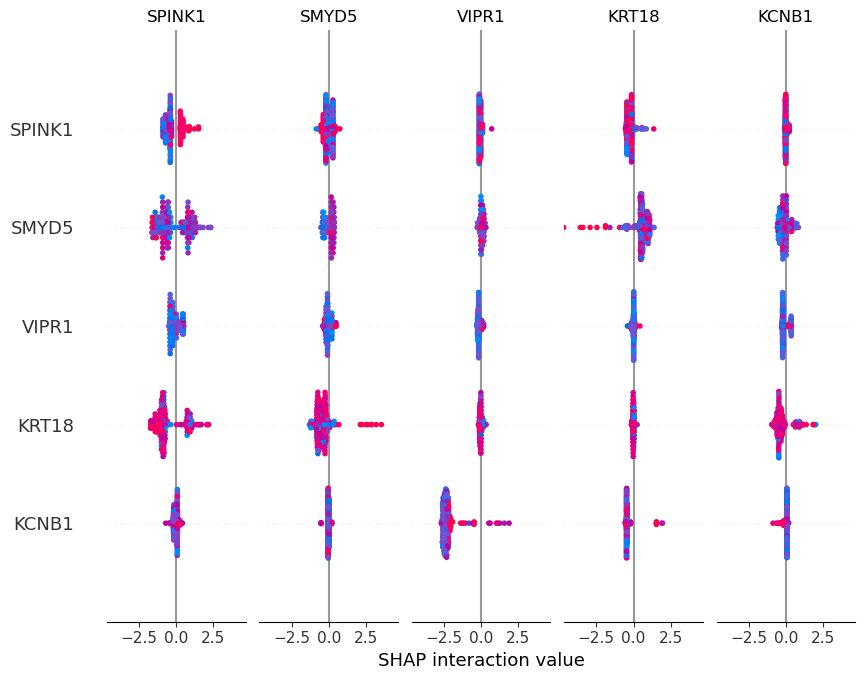

In [37]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_final)
shap.summary_plot(shap_values, X_test_final)

In [38]:
def shap_values_to_list(shap_values, model):
    shap_as_list=[]
    for i in range(len(model.classes_)):
        shap_as_list.append(shap_values[:,:,i])
    return shap_as_list

In [39]:
class_names = ("sl", "hgdn", "lgdn", "ehcc", "phcc")

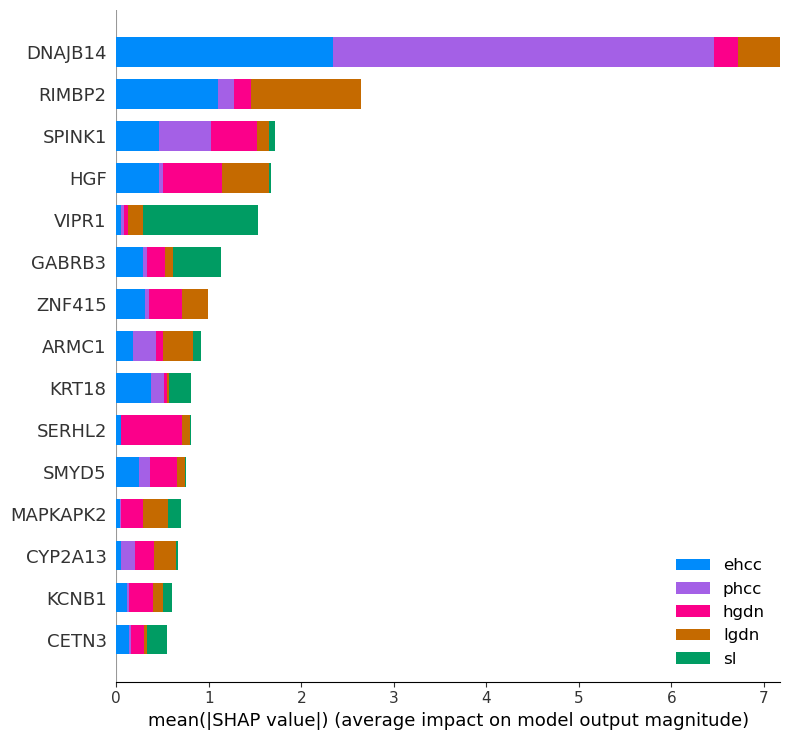

In [40]:
shap_as_list = shap_values_to_list(shap_values, final_model)
shap.summary_plot(shap_as_list, X_test_final, class_names=class_names)